# Lista 6

## scikit

(5pkt + 2pkt)

Na liście znajdują się 4 zadania. Po rozwiązaniu zadania pokaż kod prowadzącemu i odpowiedz na **pytanie kontrolne** — tylko wtedy przyznajemy punkty. Dodatkowo prześlij zadanie na platformie skos.

Zadania dodatkowe oznaczone są ⭐️. Za wykonanie każdego z nich otrzymasz 1pkt. 
**Uwaga** jedno z zadań możliwe jest do wykonania tylko podczas pracowni!

## Intro: Regresja liniowa

Wygeneruj sztuczny zbiór danych regresyjnych za pomocą funkcji `make_regression(n_samples=200, n_features=1, noise=10)`. Następnie podziel dane na zbiór treningowy i testowy (`train_test_split`) i wykonaj regresję. Policz błędy modelu na zbiorze testowym.

Który z modeli regresji daje najlepsze wyniki? Porównaj trzy modele z wykładu.

MAE  (Mean Absolute Error): 7.55
MSE  (Mean Squared Error): 7.55


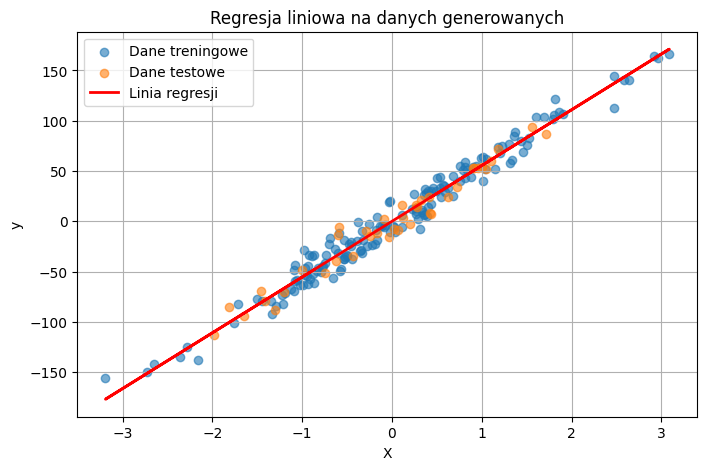

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.datasets import make_regression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# Generowanie danych
X, y = make_regression(n_samples=200, n_features=1, noise=10)

# 2. Podział danych
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)

# 3. Model regresji liniowej
model = LinearRegression(fit_intercept=True)
model.fit(X_train, y_train)

# 4. Predykcje
y_pred = model.predict(X_test)

# 5. Błędy regresji
mae = mean_absolute_error(y_test, y_pred)
mse = mean_absolute_error(y_test, y_pred)

print("MAE  (Mean Absolute Error):", round(mae, 2))
print("MSE  (Mean Squared Error):", round(mse, 2))

# 6. Wykres: dane + linia regresji
plt.figure(figsize=(8,5))
plt.scatter(X_train, y_train, alpha=0.6, label="Dane treningowe")
plt.scatter(X_test, y_test, alpha=0.6, label="Dane testowe")
plt.plot(X, model.predict(X), color='red', linewidth=2, label="Linia regresji")

plt.xlabel("X")
plt.ylabel("y")
plt.title("Regresja liniowa na danych generowanych")
plt.legend()
plt.grid(True)
plt.show()

MAE  (Mean Absolute Error): 7.46
MSE  (Mean Squared Error): 7.46


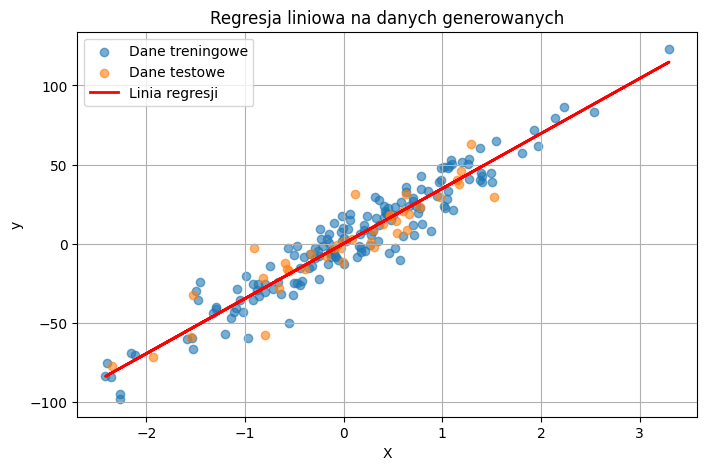

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.datasets import make_regression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge, Lasso

# Generowanie danych
X, y = make_regression(n_samples=200, n_features=1, noise=10)

# 2. Podział danych
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)

# 3. Model regresji liniowej
model = Ridge(alpha=1.0)

model.fit(X_train, y_train)

# 4. Predykcje
y_pred = model.predict(X_test)

# 5. Błędy regresji
mae = mean_absolute_error(y_test, y_pred)
mse = mean_absolute_error(y_test, y_pred)

print("MAE  (Mean Absolute Error):", round(mae, 2))
print("MSE  (Mean Squared Error):", round(mse, 2))

# 6. Wykres: dane + linia regresji
plt.figure(figsize=(8,5))
plt.scatter(X_train, y_train, alpha=0.6, label="Dane treningowe")
plt.scatter(X_test, y_test, alpha=0.6, label="Dane testowe")
plt.plot(X, model.predict(X), color='red', linewidth=2, label="Linia regresji")

plt.xlabel("X")
plt.ylabel("y")
plt.title("Regresja liniowa na danych generowanych")
plt.legend()
plt.grid(True)
plt.show()

MAE  (Mean Absolute Error): 7.8
MSE  (Mean Squared Error): 7.8


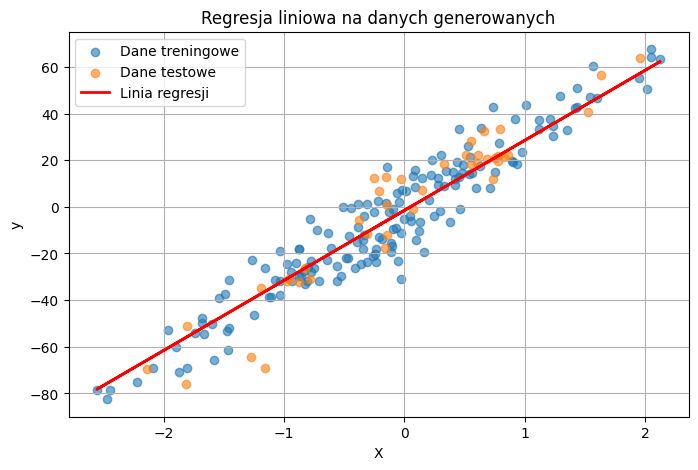

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.datasets import make_regression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge, Lasso

# Generowanie danych
X, y = make_regression(n_samples=200, n_features=1, noise=10)

# 2. Podział danych
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)

# 3. Model regresji liniowej
model = Lasso(alpha=1.0)

model.fit(X_train, y_train)

# 4. Predykcje
y_pred = model.predict(X_test)

# 5. Błędy regresji
mae = mean_absolute_error(y_test, y_pred)
mse = mean_absolute_error(y_test, y_pred)

print("MAE  (Mean Absolute Error):", round(mae, 2))
print("MSE  (Mean Squared Error):", round(mse, 2))

# 6. Wykres: dane + linia regresji
plt.figure(figsize=(8,5))
plt.scatter(X_train, y_train, alpha=0.6, label="Dane treningowe")
plt.scatter(X_test, y_test, alpha=0.6, label="Dane testowe")
plt.plot(X, model.predict(X), color='red', linewidth=2, label="Linia regresji")

plt.xlabel("X")
plt.ylabel("y")
plt.title("Regresja liniowa na danych generowanych")
plt.legend()
plt.grid(True)
plt.show()

## Rozpoznawanie ręcznie pisanych cyfr

Celem zadania jest klasyfikacja obrazów cyfr 0–9 i eksperymentowanie z parametrami klasyfikatora **SVC (Support Vector Classifier)**. W tym zadaniu będziesz pracować na zbiorze **Digits** z pakietu `sklearn`, który zawiera obrazy 8×8 pikseli wraz z prawdziwymi etykietami cyfr.

Najpierw wyświetl kilka przykładów obrazów, aby zobaczyć strukturę danych. Następnie spłaszcz obrazy 8×8 do wektorów długości 64 (`numpy.reshape` na `digits.images`) i podziel dane na zbiór treningowy i testowy.

Twoim zadaniem jest przetestowanie SVC z kilkoma (trzy wystarczą) różnymi parametrami (`C`, `gamma`) w celu znalezienia najlepszego zestawu dla tego zbioru. Dla każdej konfiguracji:

1. Przeprowadź trenowanie na zbiorze treningowym,
2. Wykonaj predykcję na zbiorze testowym,
3. Oblicz dokładność (`metrics.accuracy_score`) oraz wyświetl `metrics.classification_report`,
4. Narysuj **confusion matrix** (`metrics.ConfusionMatrixDisplay.from_predictions`).

Na końcu podsumuj:

* który zestaw parametrów dał najlepszą dokładność,
* które cyfry były najczęściej mylone,
* czy zwiększenie `C` lub zmiana `gamma` poprawiło wyniki.


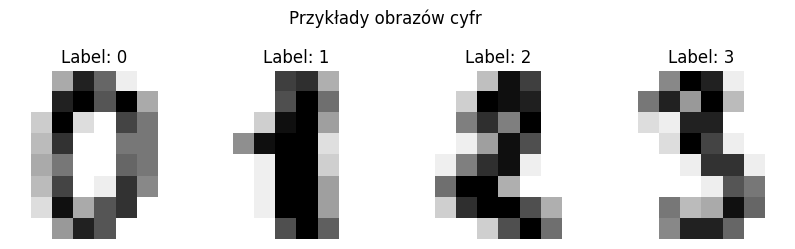

--- SVC (C=1.0, gamma=scale) ---
Accuracy: 0.9611
              precision    recall  f1-score   support

           0       0.99      0.99      0.99        88
           1       0.97      0.97      0.97        91
           2       1.00      0.98      0.99        86
           3       0.98      0.87      0.92        91
           4       0.99      0.96      0.97        92
           5       0.93      0.97      0.95        91
           6       0.99      0.99      0.99        91
           7       0.95      0.99      0.97        89
           8       0.92      0.95      0.94        88
           9       0.92      0.96      0.94        92

    accuracy                           0.96       899
   macro avg       0.96      0.96      0.96       899
weighted avg       0.96      0.96      0.96       899



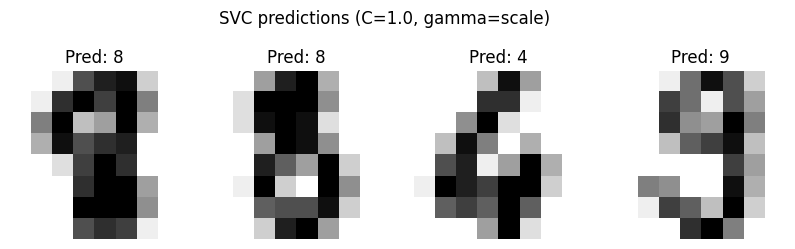

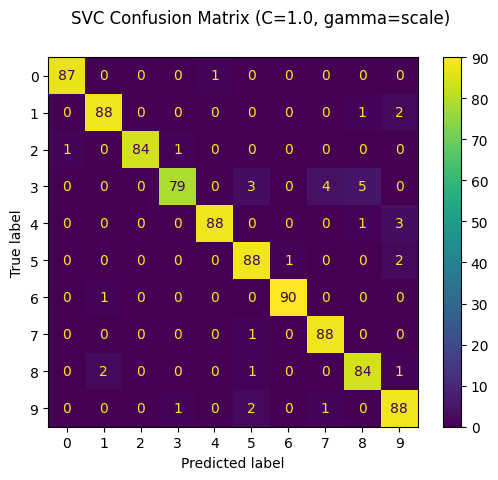

--- SVC (C=10.0, gamma=scale) ---
Accuracy: 0.9677
              precision    recall  f1-score   support

           0       0.99      0.99      0.99        88
           1       0.99      0.97      0.98        91
           2       1.00      0.98      0.99        86
           3       0.98      0.90      0.94        91
           4       0.99      0.96      0.97        92
           5       0.94      0.97      0.95        91
           6       0.99      0.99      0.99        91
           7       0.97      0.99      0.98        89
           8       0.92      0.98      0.95        88
           9       0.93      0.97      0.95        92

    accuracy                           0.97       899
   macro avg       0.97      0.97      0.97       899
weighted avg       0.97      0.97      0.97       899



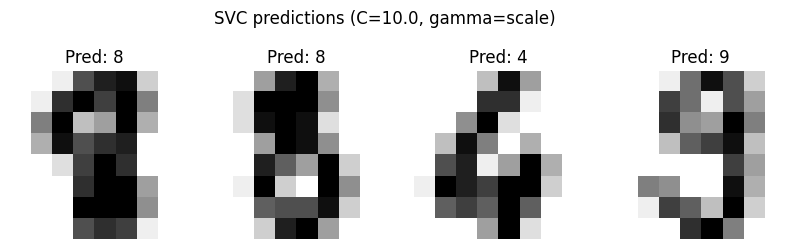

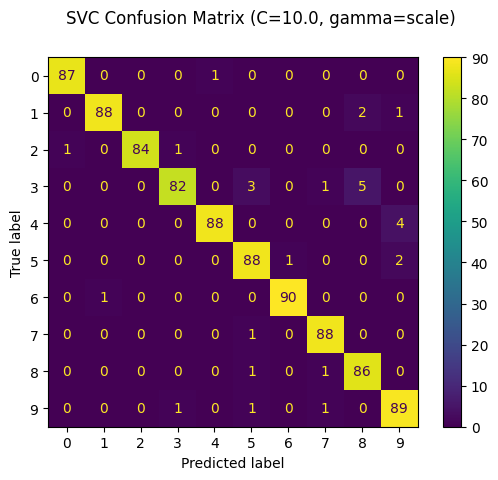

--- SVC (C=1.0, gamma=0.001) ---
Accuracy: 0.9689
              precision    recall  f1-score   support

           0       1.00      0.99      0.99        88
           1       0.99      0.97      0.98        91
           2       0.99      0.99      0.99        86
           3       0.98      0.87      0.92        91
           4       0.99      0.96      0.97        92
           5       0.95      0.97      0.96        91
           6       0.99      0.99      0.99        91
           7       0.96      0.99      0.97        89
           8       0.94      1.00      0.97        88
           9       0.93      0.98      0.95        92

    accuracy                           0.97       899
   macro avg       0.97      0.97      0.97       899
weighted avg       0.97      0.97      0.97       899



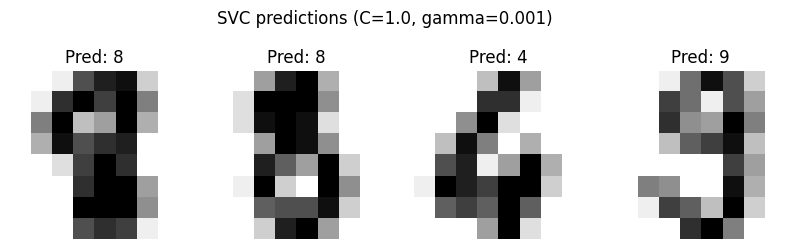

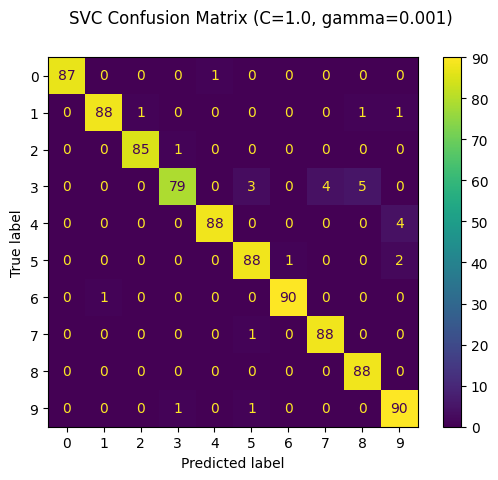

--- SVC (C=10.0, gamma=0.001) ---
Accuracy: 0.9700
              precision    recall  f1-score   support

           0       1.00      0.99      0.99        88
           1       0.99      0.96      0.97        91
           2       0.99      0.99      0.99        86
           3       0.98      0.90      0.94        91
           4       0.99      0.96      0.97        92
           5       0.95      0.96      0.95        91
           6       0.99      0.99      0.99        91
           7       0.98      0.99      0.98        89
           8       0.94      1.00      0.97        88
           9       0.92      0.98      0.95        92

    accuracy                           0.97       899
   macro avg       0.97      0.97      0.97       899
weighted avg       0.97      0.97      0.97       899



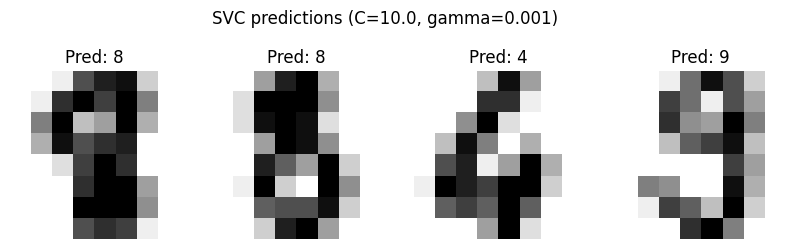

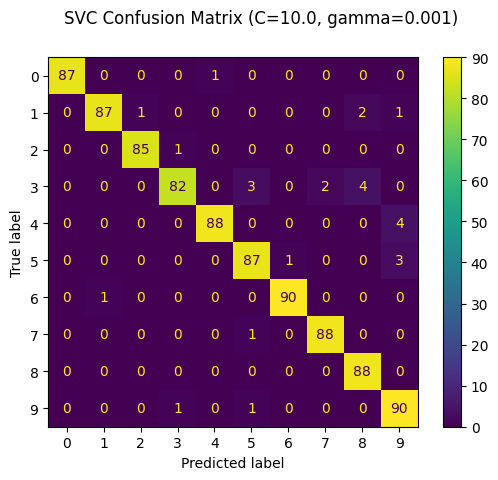

In [7]:
import matplotlib.pyplot as plt
from sklearn import datasets, metrics, svm
from sklearn.model_selection import train_test_split

# --- 1. Wczytaj dataset ---
digits = datasets.load_digits()
n_samples = len(digits.images)

# --- 2. Wizualizacja kilku obrazów ---
_, axes = plt.subplots(nrows=1, ncols=4, figsize=(10, 3))
for ax, image, label in zip(axes, digits.images, digits.target):
    ax.set_axis_off()
    ax.imshow(image, cmap=plt.cm.gray_r, interpolation="nearest")
    ax.set_title(f"Label: {label}")
plt.suptitle("Przykłady obrazów cyfr")
plt.show()

# --- 3. Spłaszcz obrazy do wektorów ---
data = digits.images.reshape((n_samples, -1))

# --- 4. Podział na zbiór treningowy i testowy ---
X_train, X_test, y_train, y_test = train_test_split(
    data, digits.target, test_size=0.5, shuffle=False
)

# --- 5. Testowanie SVC z różnymi parametrami ---
svc_params = [
    # Uzupełnij
    {"C": 1.0, "gamma": "scale"},
    {"C": 10.0, "gamma": "scale"},
    {"C": 1.0, "gamma": 0.001},
    {"C": 10.0, "gamma": 0.001},
]

for params in svc_params:
    clf = svm.SVC(C=params["C"], gamma=params["gamma"])
    clf.fit(X_train, y_train)
    predicted = clf.predict(X_test)

    accuracy = metrics.accuracy_score(y_test, predicted)
    classification_report = metrics.classification_report(y_test, predicted)
    print(f"--- SVC (C={params['C']}, gamma={params['gamma']}) ---")
    print(f"Accuracy: {accuracy:.4f}")
    print(classification_report)

    # Wyświetlenie pierwszych 4 obrazów testowych z predykcjami
    _, axes = plt.subplots(nrows=1, ncols=4, figsize=(10, 3))
    for ax, image, prediction in zip(axes, X_test, predicted):
        ax.set_axis_off()
        image = image.reshape(8, 8)
        ax.imshow(image, cmap=plt.cm.gray_r, interpolation="nearest")
        ax.set_title(f"Pred: {prediction}")
    plt.suptitle(f"SVC predictions (C={params['C']}, gamma={params['gamma']})")
    plt.show()

    # Confusion matrix
    disp = metrics.ConfusionMatrixDisplay.from_predictions(y_test, predicted)
    disp.figure_.suptitle(f"SVC Confusion Matrix (C={params['C']}, gamma={params['gamma']})")
    plt.show()

## Porównanie metod klastrowania

Celem zadania jest **porównanie różnych metod klasteryzacji** na prostych zbiorach danych.
Aby to umożliwić, przygotowano **trzy przykładowe datasety**, zróżnicowane pod względem struktury i trudności zadania:

1. **`blobs`** – zbiór punktów pogrupowanych w wyraźnie rozdzielone klastry (w miarę „idealny” przypadek klasteryzacji).
2. **`moons`** – dane w kształcie dwóch półksiężyców, które tworzą nieliniową strukturę i są trudniejsze dla metod zakładających kuliste klastry.
3. **`circles`** – dane w kształcie dwóch koncentrycznych okręgów, trudne do analizy dla algorytmów bazujących na odległości euklidesowej.

Twoim zadaniem jest **przetestowanie kilku metod klasteryzacji** na każdym z datasetów, a następnie **porównanie wyników wizualnie** – czyli na wykresach przedstawiających pogrupowane punkty.

---

#### Metody klasteryzacji do przetestowania

##### KMeans

Parametr: `n_clusters` – liczba oczekiwanych klastrów.

##### DBSCAN

Parametry:

   * `eps` – maksymalna odległość między punktami, aby zostały uznane za należące do tego samego klastra;
   * `min_samples` – minimalna liczba punktów w sąsiedztwie, aby uznać grupę za klaster.

##### Agglomerative Clustering

Parametr: `n_clusters` – liczba oczekiwanych klastrów.

##### Gaussian Mixture Model (GMM)

Parametr: `n_components` (odpowiednik liczby klastrów).

##### Spectral Clustering

Parametr: `n_clusters`.


#### Zadanie do wykonania

Przygotuj dane. W tym celu wykorzystaj `StandardScaler()`.

Następnie dla każdego z trzech datasetów:

   * zastosuj wszystkie podane metody klasteryzacji,
   * do przewidywania predykcji skorzystaj z metody `fit_predict`, która zwróci od razu predyk
   * dobierz parametry tak, aby uzyskać możliwie sensowny podział,
   * narysuj wyniki klasteryzacji na wykresach.

Która metoda sprawdza się najlepiej dla każdego z trzech datasetów?

   Możesz brać pod uwagę:

   * kształt klastrów,
   * obecność szumu,
   * poprawność wykrycia struktur widocznych na wykresie,
   * wrażliwość metody na parametry.

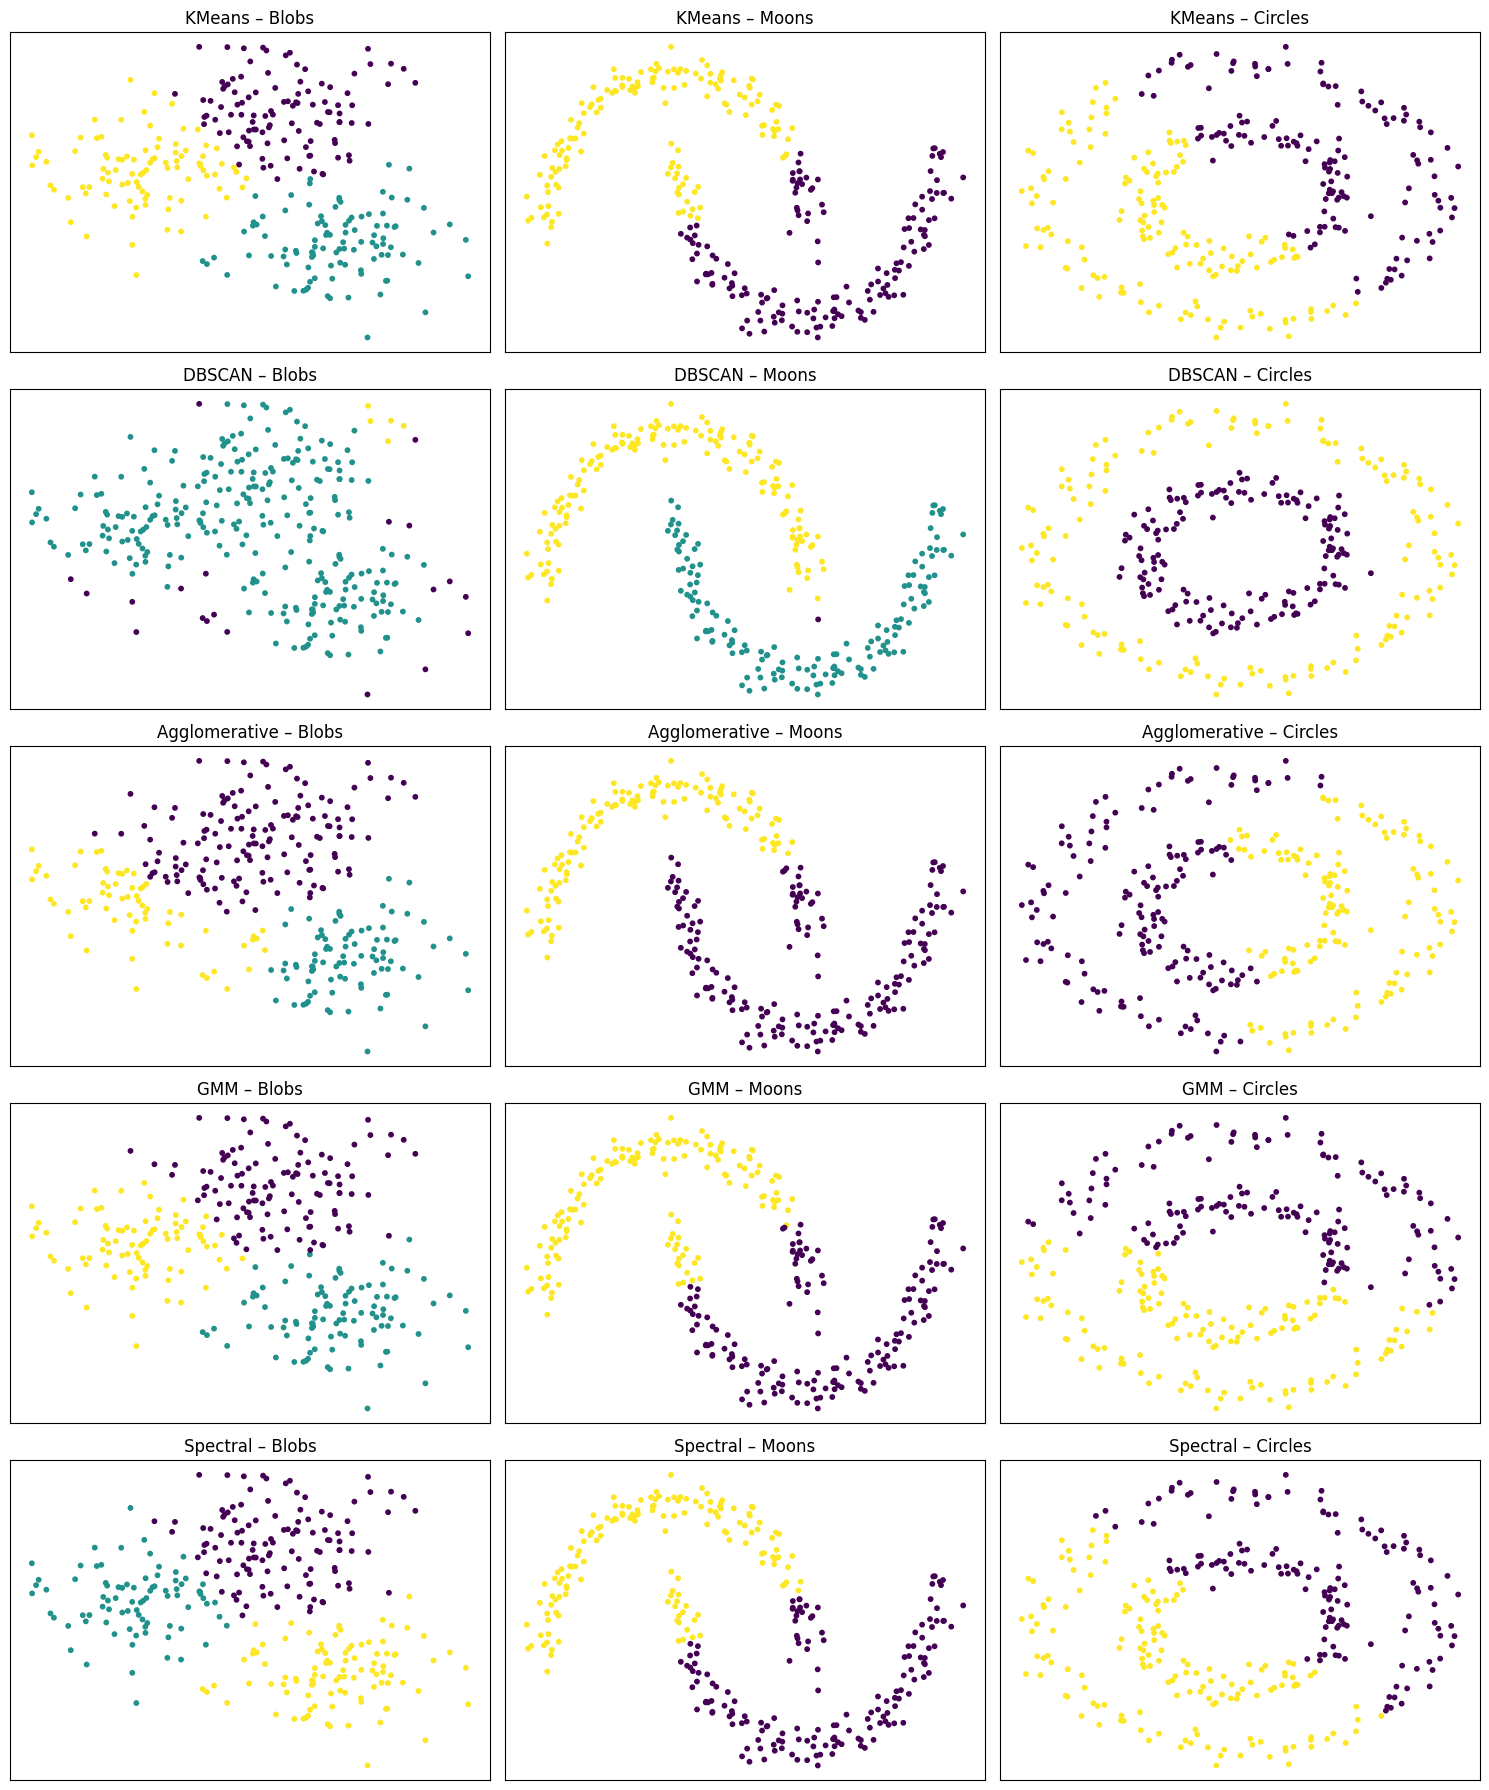

In [27]:
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering, SpectralClustering
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

# --- 1. Datasets ---
blobs_X, _ = datasets.make_blobs(n_samples=300, centers=3, random_state=0)
moons_X, _ = datasets.make_moons(n_samples=300, noise=0.07, random_state=0)
circles_X, _ = datasets.make_circles(n_samples=300, noise=0.07, factor=0.5, random_state=0)

datasets_list = [
    ("Blobs", blobs_X),
    ("Moons", moons_X),
    ("Circles", circles_X)
]

methods = ["KMeans", "DBSCAN", "Agglomerative", "GMM", "Spectral"]

plt.figure(figsize=(15, 18))

for col_idx, (ds_name, X) in enumerate(datasets_list):
    k = 2 if ds_name != "Blobs" else 3
    standardscaler = StandardScaler()
    X_scaled = standardscaler.fit_transform(X)

    # Przygotowanie etykiet metod
    # --- KMeans ---
    kmeans = KMeans(n_clusters=k, n_init=3)
    kmeans_labels = kmeans.fit_predict(X_scaled)

    # --- DBSCAN ---
    dbscan = DBSCAN(min_samples=5, eps=0.35)
    dbscan_labels = dbscan.fit_predict(X_scaled)
    # --- Agglomerative ---
    agg = AgglomerativeClustering(n_clusters=k)
    agg_labels = agg.fit_predict(X_scaled)

    # --- GMM ---
    gmm = GaussianMixture(n_components=k, n_init=3)
    gmm_labels = gmm.fit_predict(X_scaled)

    # --- Spectral ---
    spectral = SpectralClustering(n_clusters=k, n_init=3)
    spectral_labels = spectral.fit_predict(X_scaled)

    results = [
        ("KMeans", kmeans_labels),
        ("DBSCAN", dbscan_labels),
        ("Agglomerative", agg_labels),
        ("GMM", gmm_labels),
        ("Spectral", spectral_labels)
    ]

    # Rysowanie 5 wierszy × 3 kolumny
    for row_idx, (method_name, labels) in enumerate(results):
        plt.subplot(len(results), len(datasets_list), row_idx * len(datasets_list) + col_idx + 1)
        plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels, s=10)
        plt.title(f"{method_name} – {ds_name}")
        plt.xticks([])
        plt.yticks([])

plt.tight_layout()
plt.show()


## Najlepsze wino

Celem zadania jest **znalezienie najlepszej kombinacji operacji przetwarzania danych i klasyfikatora** dla zbioru **Wine Quality Red**.

**Uwaga**
Komplet punktów (2pkt) otrzymasz tylko za osiągnięcie wyniku powyżej 90%.

⭐️ W każdej grupie trzy osoby, które otrzymają najlepszy wynik do końca trwania ćwiczeń, otrzymają punkt bonusowy. Ten sam punkt otrzyma kada osoba, która pżekroczy próg 96%.

---

#### Opis zadania

1. Wczytaj zbiór danych **Wine Quality Red** z OpenML (`data_id=41116`).
2. Zamień etykiety jakości wina na **klasyfikację binarną**: dobra (>=6) / słaba (<6).
3. Podziel dane na zbiór treningowy i testowy.
4. Na początek zastosuj **baseline**:

   * bez skalowania,
   * bez redukcji wymiarów,
   * prosty klasyfikator, np. `RandomForestClassifier(n_estimators=100)`.
     Oblicz dokładność i classification_report.
5. Następnie stwórz **pipeline**.
6. Porównaj wyniki z baseline i wybierz najlepszą kombinację parametrów, którą uważasz za optymalną.
7. Zapisz wyniki i wnioski: które kombinacje poprawiają dokładność, a które pogarszają.

# ⭐️ Oczyszczanie obrazów cyfr

Celem zadania jest **przetestowanie metod denoisingu obrazów cyfr** przy użyciu klasycznego PCA i Kernel PCA. Będziesz pracować na zbiorze **USPS digits**, który zawiera obrazy 16×16 pikseli przedstawiające cyfry 0–9.

## **Kilka wyjaśnień:**

* **PCA (Principal Component Analysis)**: klasyczna metoda redukcji wymiarów, która znajduje główne kierunki wariancji w danych. W denoisingu obrazy są przybliżane przez wybrane komponenty, co pozwala odfiltrować szum.

* **Kernel PCA**: rozszerzenie PCA, które działa w **przestrzeni cech nieliniowych** dzięki funkcji jądra (`kernel`). Dzięki temu metoda może uchwycić bardziej złożone, nieliniowe struktury w danych, co czasem pozwala na lepsze oczyszczenie szumu.

* **`inverse_transform`**: metoda, która pozwala **odtworzyć pierwotne dane** z przestrzeni zredukowanych cech. W PCA i Kernel PCA możemy więc zamienić reprezentację niskowymiarową z powrotem na obraz w oryginalnej przestrzeni pikseli.

---

# **Twoje zadania**

1. **Wczytaj dane USPS** i przeskaluj je do zakresu (0, 1).
2. **Podziel dane** na zbiór treningowy i testowy.
3. **Dodaj szum gaussowski** do obu zbiorów, tworząc wersje zaszumione.
4. **Wyświetl przykładowe obrazy** oryginalne i zaszumione, aby zobaczyć efekt szumu.
5. **Naucz PCA i Kernel PCA** na zaszumionych obrazach treningowych.
6. **Zrekonstruuj obrazy testowe** używając `inverse_transform` i oblicz MSE (Mean Squared Error).
7. **Porównaj wizualnie i ilościowo** jakość rekonstrukcji i napisz krótkie wnioski.

(1697, 64)


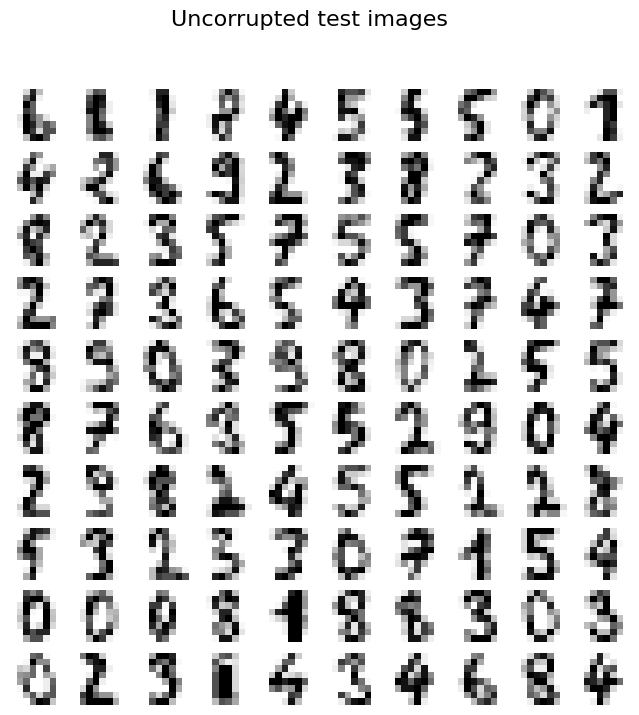

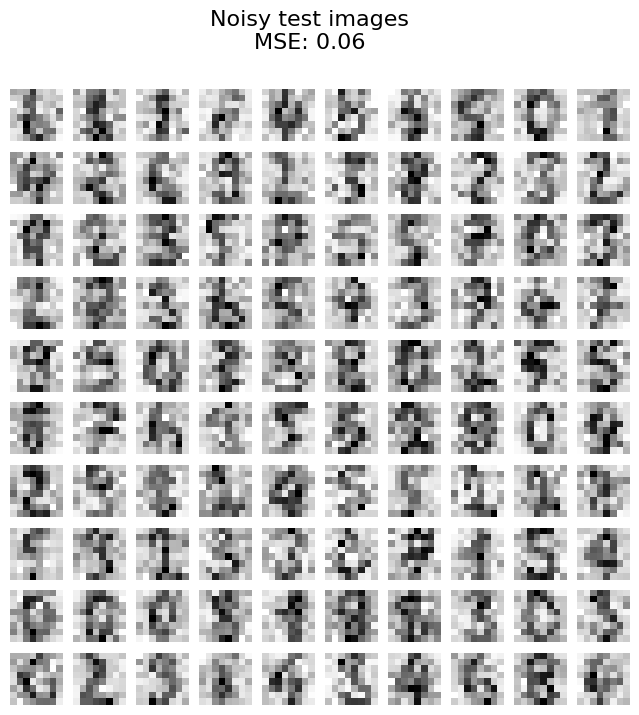

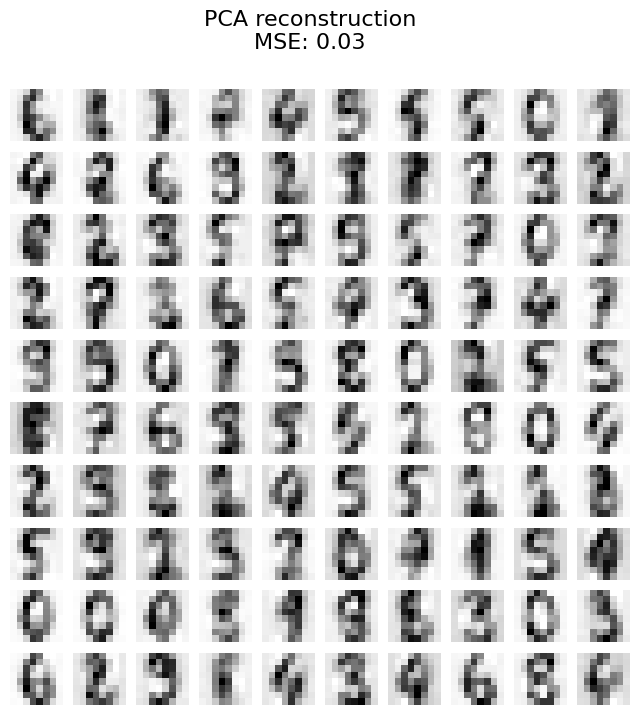

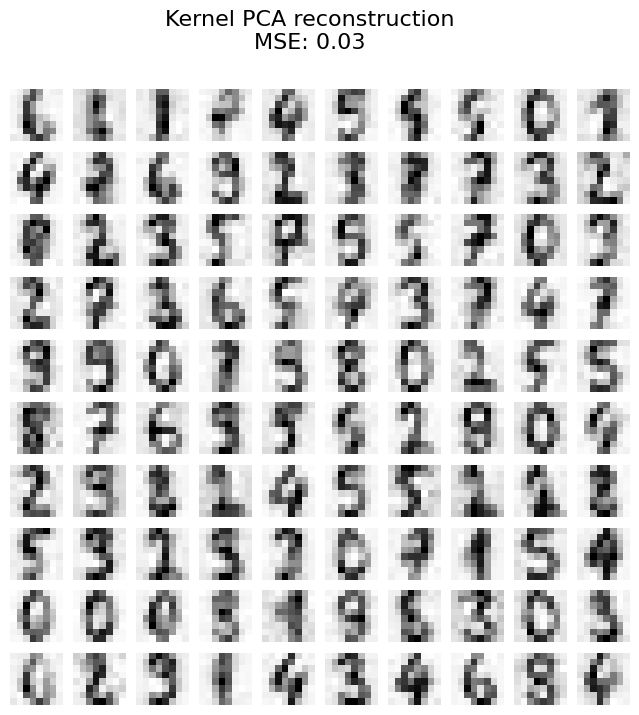

In [91]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA, KernelPCA
from sklearn.datasets import load_digits


# -----------------------------
# 1. Wczytanie i przygotowanie danych
# -----------------------------
# To już nie działa
# X, y = fetch_openml(data_id=41082, as_frame=False, return_X_y=True)
# Dlatego używam alternatywnego sposobu
X, y = load_digits(return_X_y=True, as_frame=False)
X = MinMaxScaler().fit_transform(X)

# -----------------------------
# 2. Podział na zbiór treningowy i testowy
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=100, random_state=21)
print(X_train.shape)
# -----------------------------
# 3. Dodanie szumu
# -----------------------------
rng = np.random.RandomState(0)
X_train_noisy = X_train + rng.normal(scale=0.25, size=X_train.shape)
X_test_noisy = X_test + rng.normal(scale=0.25, size=X_test.shape)

# -----------------------------
# 4. Funkcja pomocnicza do wizualizacji obrazów
# -----------------------------
def plot_digits(X, title):
    """Wyświetla 100 obrazów w siatce 10x10."""
    fig, axs = plt.subplots(nrows=10, ncols=10, figsize=(8, 8))
    for img, ax in zip(X, axs.ravel()):
        ax.imshow(img.reshape((8, 8)), cmap="Greys")
        ax.axis("off")
    fig.suptitle(title, fontsize=16)
    plt.show()

# -----------------------------
# 5. Wyświetlenie przykładowych obrazów
# -----------------------------

plot_digits(X_test, "Uncorrupted test images")
mse_noisy = np.mean((X_test - X_test_noisy) ** 2)
plot_digits(X_test_noisy, f"Noisy test images\nMSE: {mse_noisy:.2f}")

# -----------------------------
# 6. Nauczenie PCA i Kernel PCA
# -----------------------------
pca = PCA(n_components=8)
kernel_pca = KernelPCA(n_components=8, kernel="poly", gamma=0.1, fit_inverse_transform=True)


pca.fit(X_train_noisy)
kernel_pca.fit(X_train_noisy)

# -----------------------------
# 7. Rekonstrukcja obrazów testowych
# -----------------------------
X_reconstructed_pca = pca.inverse_transform(pca.transform(X_test_noisy))
X_reconstructed_kernel_pca = kernel_pca.inverse_transform(kernel_pca.transform(X_test_noisy))

# -----------------------------
# 8. Wyświetlenie wyników i MSE
# -----------------------------

# plot_digits(X_test, "Uncorrupted test images")
plot_digits(
    X_reconstructed_pca,
    f"PCA reconstruction\nMSE: {np.mean((X_test - X_reconstructed_pca) ** 2):.2f}",
)
plot_digits(
    X_reconstructed_kernel_pca,
    f"Kernel PCA reconstruction\nMSE: {np.mean((X_test - X_reconstructed_kernel_pca) ** 2):.2f}",
)

### Wnioski
- PCA i PCA_Kernel otrzymały ten sam wynik, pomimo testowania różnych kombinacji parametrów
- W takim razie można stwierdzić, że nie ma tutaj zależności nie liniowej, w której 
PCA_Kernel prawdopodobnie poradziłby sobie lepiej